In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('monthly_average_BATS_cleaned.csv')
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


In [6]:
columns_to_drop =['CO2_rolling', 'Alkalinity_rolling']
df = df.drop(columns=columns_to_drop)
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992


Alkalinity column statistics:
count     378.000000
mean     2382.881105
std        15.555445
min      2346.539394
25%      2369.885007
50%      2389.590513
75%      2393.850000
max      2409.700000
Name: Alkalinity, dtype: float64

Alkalinity column data type: float64

Number of non-null values: 378
Number of null values: 0


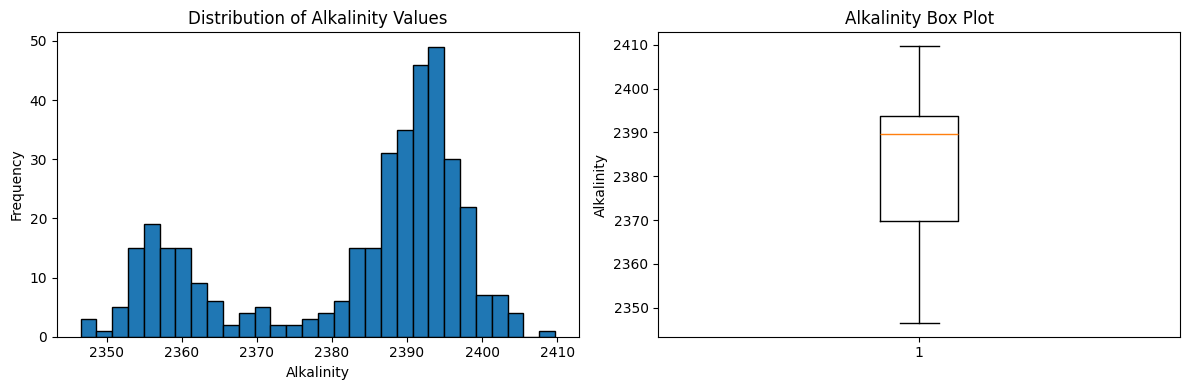

In [17]:
print("Alkalinity column statistics:")
print(df['Alkalinity'].describe())
print("\nAlkalinity column data type:", df['Alkalinity'].dtype)
print("\nNumber of non-null values:", df['Alkalinity'].count())
print("Number of null values:", df['Alkalinity'].isnull().sum())


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Alkalinity'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Alkalinity Values')
plt.xlabel('Alkalinity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['Alkalinity'].dropna())
plt.title('Alkalinity Box Plot')
plt.ylabel('Alkalinity')

plt.tight_layout()
plt.savefig('alkalinity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df['Alkalinity_category'] = df['Alkalinity'].apply(lambda x: 'Low' if x < 2375 else 'High')

print("Alkalinity categorical distribution:")
print(df['Alkalinity_category'].value_counts())
print(f"\nPercentage distribution:")
print(df['Alkalinity_category'].value_counts(normalize=True) * 100)

Alkalinity categorical distribution:
Alkalinity_category
High    276
Low     102
Name: count, dtype: int64

Percentage distribution:
Alkalinity_category
High    73.015873
Low     26.984127
Name: proportion, dtype: float64


In [14]:
feature_columns = ["depth", "Temperature", "Salinity", "Oxygen_1", "CO2", 
                  "NO3_plus_NO2", "NO2", "PO4", "Silicate", "POC", "PON", "TOC", "Bact_Enum"]
target_column = "Alkalinity_category"

X = df[feature_columns]
y = df[target_column]

print("Features selected:")
print(feature_columns)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTesting set target distribution:")
print(y_test.value_counts())

Features selected:
['depth', 'Temperature', 'Salinity', 'Oxygen_1', 'CO2', 'NO3_plus_NO2', 'NO2', 'PO4', 'Silicate', 'POC', 'PON', 'TOC', 'Bact_Enum']

Feature matrix shape: (378, 13)
Target vector shape: (378,)

Training set size: 302 samples
Testing set size: 76 samples

Training set target distribution:
Alkalinity_category
High    221
Low      81
Name: count, dtype: int64

Testing set target distribution:
Alkalinity_category
High    55
Low     21
Name: count, dtype: int64


In [ ]:
nb_classifier = GaussianNB()

nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)
y_pred_proba = nb_classifier.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Classifier Results:")
print("=" * 40)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

y_test_binary = (y_test == 'High').astype(int)
y_proba_high = y_pred_proba[:, 1]
auc_score = roc_auc_score(y_test_binary, y_proba_high)
print(f"\nAUC Score: {auc_score:.4f}")

print("\nPrediction probabilities for first 10 test samples:")
print("Actual | Predicted | Prob(Low) | Prob(High)")
print("-" * 45)
for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    prob_low = y_pred_proba[i][0]
    prob_high = y_pred_proba[i][1]
    print(f"{actual:6} | {predicted:9} | {prob_low:.3f}     | {prob_high:.3f}")

Naive Bayes Classifier Results:
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        55
         Low       0.95      0.95      0.95        21

    accuracy                           0.97        76
   macro avg       0.97      0.97      0.97        76
weighted avg       0.97      0.97      0.97        76

Confusion Matrix:
[[54  1]
 [ 1 20]]

AUC Score: 0.0052

Prediction probabilities for first 10 test samples:
Actual | Predicted | Prob(Low) | Prob(High)
---------------------------------------------
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
Low    | Low       | 0.000     | 1.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
Low    | Low       | 0.000     | 1.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000



FEATURE IMPORTANCE ANALYSIS

Method 1: Feature Importance based on Class Mean Differences
-------------------------------------------------------
CO2             | 60.0433 | 0.6873
depth           | 16.4222 | 0.1880
POC             | 2.6675 | 0.0305
Oxygen_1        | 2.2919 | 0.0262
Silicate        | 1.4100 | 0.0161
TOC             | 1.2334 | 0.0141
NO3_plus_NO2    | 1.1249 | 0.0129
Bact_Enum       | 0.8199 | 0.0094
PON             | 0.6741 | 0.0077
Temperature     | 0.5299 | 0.0061
PO4             | 0.0927 | 0.0011
Salinity        | 0.0475 | 0.0005
NO2             | 0.0063 | 0.0001

Method 2: Feature Importance based on Log Probability Variance
------------------------------------------------------------
CO2             | 901.300228 | 0.9260
depth           | 67.421936 | 0.0693
POC             | 1.778910 | 0.0018
Oxygen_1        | 1.313224 | 0.0013
Silicate        | 0.497038 | 0.0005
TOC             | 0.380315 | 0.0004
NO3_plus_NO2    | 0.316323 | 0.0003
Bact_Enum       | 0.168069 | 

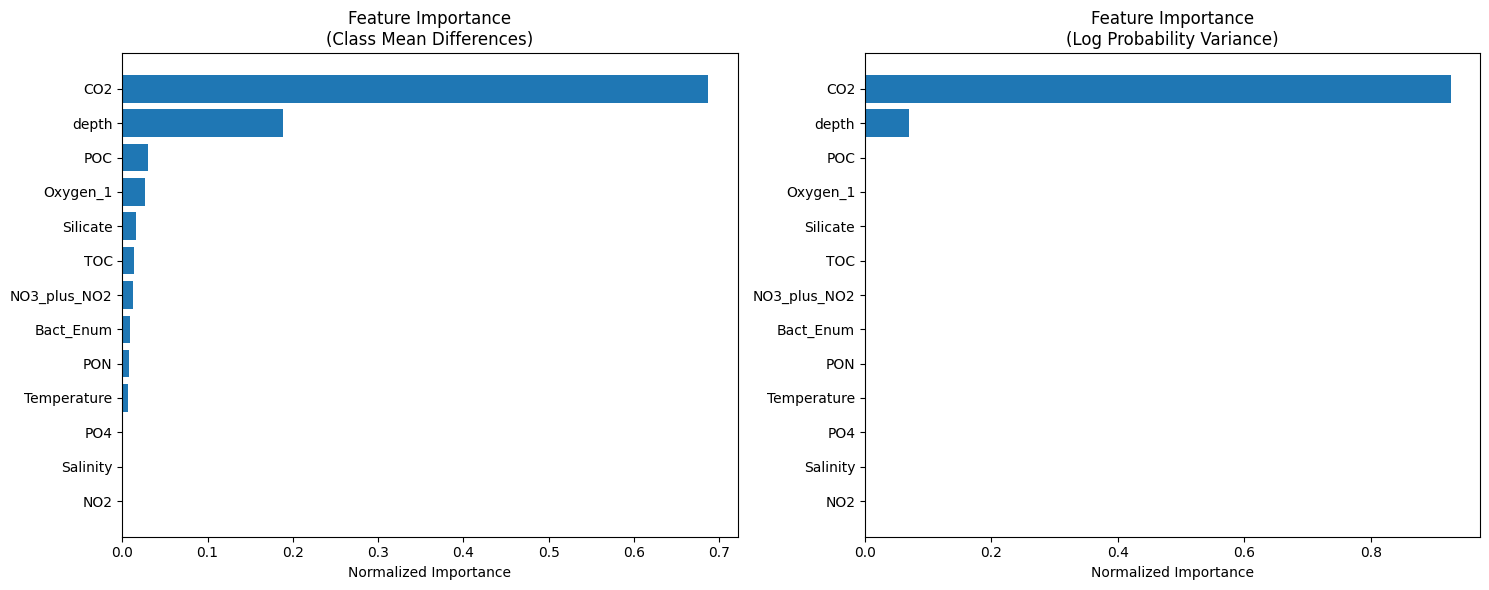


TOP 5 MOST IMPORTANT FEATURES:
----------------------------------------
Based on Class Mean Differences:
1. CO2 (0.687)
2. depth (0.188)
3. POC (0.031)
4. Oxygen_1 (0.026)
5. Silicate (0.016)

Based on Log Probability Variance:
1. CO2 (0.926)
2. depth (0.069)
3. POC (0.002)
4. Oxygen_1 (0.001)
5. Silicate (0.001)


In [ ]:
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

class_means = {}
for class_label in nb_classifier.classes_:
    class_data = X_train[y_train == class_label]
    class_means[class_label] = class_data.mean()

mean_diff = abs(class_means['High'] - class_means['Low'])
mean_diff_normalized = mean_diff / mean_diff.sum()

print("\nMethod 1: Feature Importance based on Class Mean Differences")
print("-" * 55)
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Mean_Difference': mean_diff.values,
    'Normalized_Importance': mean_diff_normalized.values
}).sort_values('Normalized_Importance', ascending=False)

for i, row in feature_importance_df.iterrows():
    print(f"{row['Feature']:15} | {row['Mean_Difference']:.4f} | {row['Normalized_Importance']:.4f}")

print("\nMethod 2: Feature Importance based on Log Probability Variance")
print("-" * 60)


log_prob_variance = []
for i, feature in enumerate(feature_columns):
    theta_variance = np.var(nb_classifier.theta_[:, i])
    log_prob_variance.append(theta_variance)

log_prob_variance = np.array(log_prob_variance)
log_prob_normalized = log_prob_variance / log_prob_variance.sum()

feature_importance_df2 = pd.DataFrame({
    'Feature': feature_columns,
    'Log_Prob_Variance': log_prob_variance,
    'Normalized_Importance': log_prob_normalized
}).sort_values('Normalized_Importance', ascending=False)

for i, row in feature_importance_df2.iterrows():
    print(f"{row['Feature']:15} | {row['Log_Prob_Variance']:.6f} | {row['Normalized_Importance']:.4f}")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.barh(feature_importance_df['Feature'], feature_importance_df['Normalized_Importance'])
plt.title('Feature Importance\n(Class Mean Differences)')
plt.xlabel('Normalized Importance')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(feature_importance_df2['Feature'], feature_importance_df2['Normalized_Importance'])
plt.title('Feature Importance\n(Log Probability Variance)')
plt.xlabel('Normalized Importance')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nTOP 5 MOST IMPORTANT FEATURES:")
print("-" * 40)
print("Based on Class Mean Differences:")
for i in range(min(5, len(feature_importance_df))):
    row = feature_importance_df.iloc[i]
    print(f"{i+1}. {row['Feature']} ({row['Normalized_Importance']:.3f})")

print("\nBased on Log Probability Variance:")
for i in range(min(5, len(feature_importance_df2))):
    row = feature_importance_df2.iloc[i]
    print(f"{i+1}. {row['Feature']} ({row['Normalized_Importance']:.3f})")

Confusion matrix saved as 'naive_bayes_confusion_matrix.png'


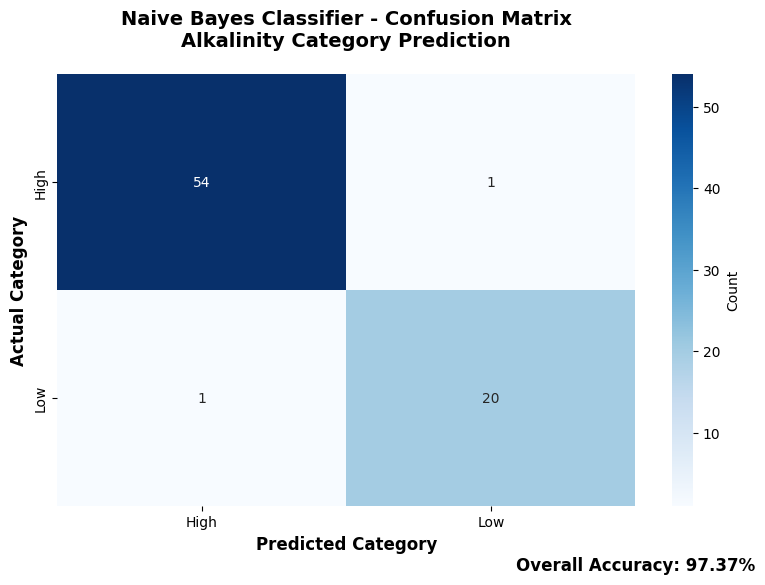

Alternative confusion matrix saved as 'naive_bayes_confusion_matrix_alt.png'


<Figure size 800x600 with 0 Axes>

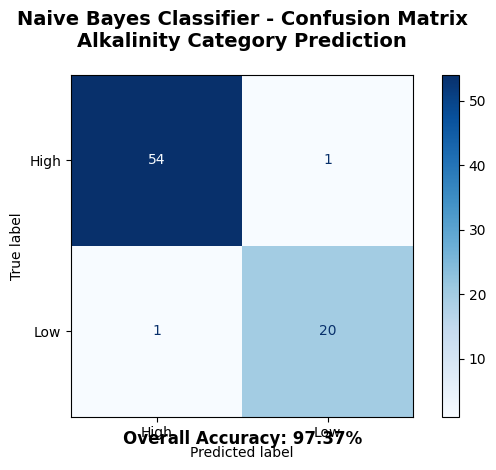

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High', 'Low'], yticklabels=['High', 'Low'],
            cbar_kws={'label': 'Count'})

plt.title('Naive Bayes Classifier - Confusion Matrix\nAlkalinity Category Prediction', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')

plt.text(1, -0.15, f'Overall Accuracy: {accuracy:.2%}', 
         horizontalalignment='center', fontsize=12, fontweight='bold',
         transform=plt.gca().transAxes)

plt.tight_layout()

plt.savefig('naive_bayes_confusion_matrix.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Confusion matrix saved as 'naive_bayes_confusion_matrix.png'")
plt.show()

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Naive Bayes Classifier - Confusion Matrix\nAlkalinity Category Prediction', 
          fontsize=14, fontweight='bold', pad=20)

plt.text(0.5, -0.08, f'Overall Accuracy: {accuracy:.2%}', 
         horizontalalignment='center', fontsize=12, fontweight='bold',
         transform=plt.gca().transAxes)

plt.tight_layout()

plt.savefig('naive_bayes_confusion_matrix_alt.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Alternative confusion matrix saved as 'naive_bayes_confusion_matrix_alt.png'")
plt.show()

Classification report visualization saved as 'naive_bayes_classification_report.png'


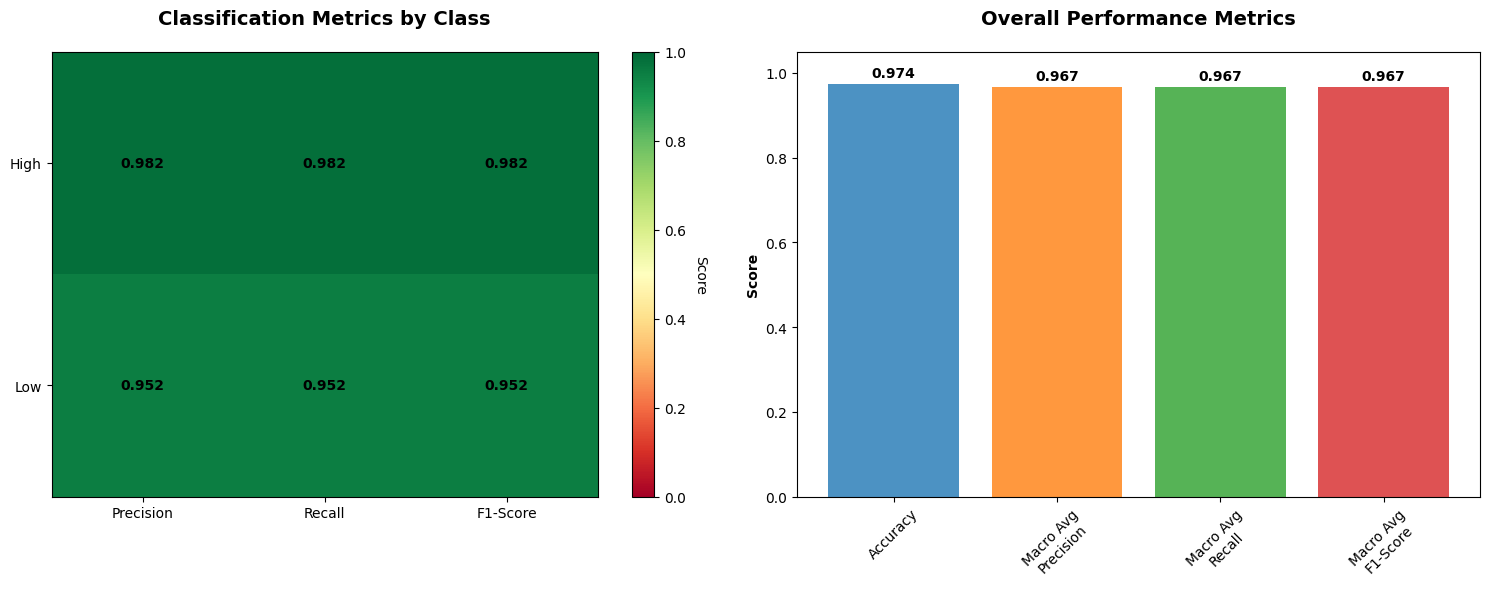

Classification report table saved as 'naive_bayes_classification_report_table.png'


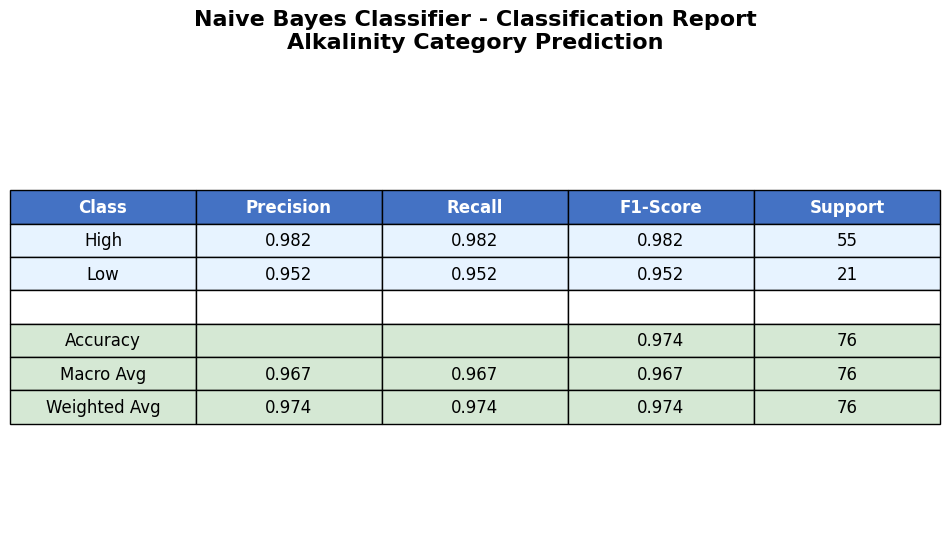

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support


report_dict = classification_report(y_test, y_pred, output_dict=True)


classes = ['High', 'Low']
metrics = ['Precision', 'Recall', 'F1-Score']


data = []
for class_name in classes:
    row = [
        report_dict[class_name]['precision'],
        report_dict[class_name]['recall'],
        report_dict[class_name]['f1-score']
    ]
    data.append(row)


overall_row = [
    report_dict['weighted avg']['precision'],
    report_dict['weighted avg']['recall'],
    report_dict['weighted avg']['f1-score']
]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


import numpy as np
data_array = np.array(data)
im1 = ax1.imshow(data_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)


ax1.set_xticks(range(len(metrics)))
ax1.set_yticks(range(len(classes)))
ax1.set_xticklabels(metrics)
ax1.set_yticklabels(classes)


for i in range(len(classes)):
    for j in range(len(metrics)):
        text = ax1.text(j, i, f'{data_array[i, j]:.3f}',
                       ha="center", va="center", color="black", fontweight='bold')

ax1.set_title('Classification Metrics by Class', fontsize=14, fontweight='bold', pad=20)


cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Score', rotation=270, labelpad=15)


overall_metrics = ['Accuracy', 'Macro Avg\nPrecision', 'Macro Avg\nRecall', 'Macro Avg\nF1-Score']
overall_values = [
    report_dict['accuracy'],
    report_dict['macro avg']['precision'],
    report_dict['macro avg']['recall'],
    report_dict['macro avg']['f1-score']
]

bars = ax2.bar(overall_metrics, overall_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Overall Performance Metrics', fontsize=14, fontweight='bold', pad=20)


for bar, value in zip(bars, overall_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')


ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()


plt.savefig('naive_bayes_classification_report.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Classification report visualization saved as 'naive_bayes_classification_report.png'")
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')


table_data = []
table_data.append(['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])
table_data.append(['High', f"{report_dict['High']['precision']:.3f}", 
                   f"{report_dict['High']['recall']:.3f}", 
                   f"{report_dict['High']['f1-score']:.3f}", 
                   f"{int(report_dict['High']['support'])}"])
table_data.append(['Low', f"{report_dict['Low']['precision']:.3f}", 
                   f"{report_dict['Low']['recall']:.3f}", 
                   f"{report_dict['Low']['f1-score']:.3f}", 
                   f"{int(report_dict['Low']['support'])}"])
table_data.append(['', '', '', '', ''])
table_data.append(['Accuracy', '', '', f"{report_dict['accuracy']:.3f}", 
                   f"{int(report_dict['macro avg']['support'])}"])
table_data.append(['Macro Avg', f"{report_dict['macro avg']['precision']:.3f}", 
                   f"{report_dict['macro avg']['recall']:.3f}", 
                   f"{report_dict['macro avg']['f1-score']:.3f}", 
                   f"{int(report_dict['macro avg']['support'])}"])
table_data.append(['Weighted Avg', f"{report_dict['weighted avg']['precision']:.3f}", 
                   f"{report_dict['weighted avg']['recall']:.3f}", 
                   f"{report_dict['weighted avg']['f1-score']:.3f}", 
                   f"{int(report_dict['weighted avg']['support'])}"])


table = ax.table(cellText=table_data, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)


for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')


for i in range(5):
    table[(1, i)].set_facecolor('#E7F3FF')
    table[(2, i)].set_facecolor('#E7F3FF')


for i in range(5):
    table[(4, i)].set_facecolor('#D5E8D4')
    table[(5, i)].set_facecolor('#D5E8D4')
    table[(6, i)].set_facecolor('#D5E8D4')

plt.title('Naive Bayes Classifier - Classification Report\nAlkalinity Category Prediction', 
          fontsize=16, fontweight='bold', pad=20)


plt.savefig('naive_bayes_classification_report_table.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Classification report table saved as 'naive_bayes_classification_report_table.png'")
plt.show()

Comprehensive feature importance visualization saved as 'naive_bayes_feature_importance_comprehensive.png'


<Figure size 1600x800 with 0 Axes>

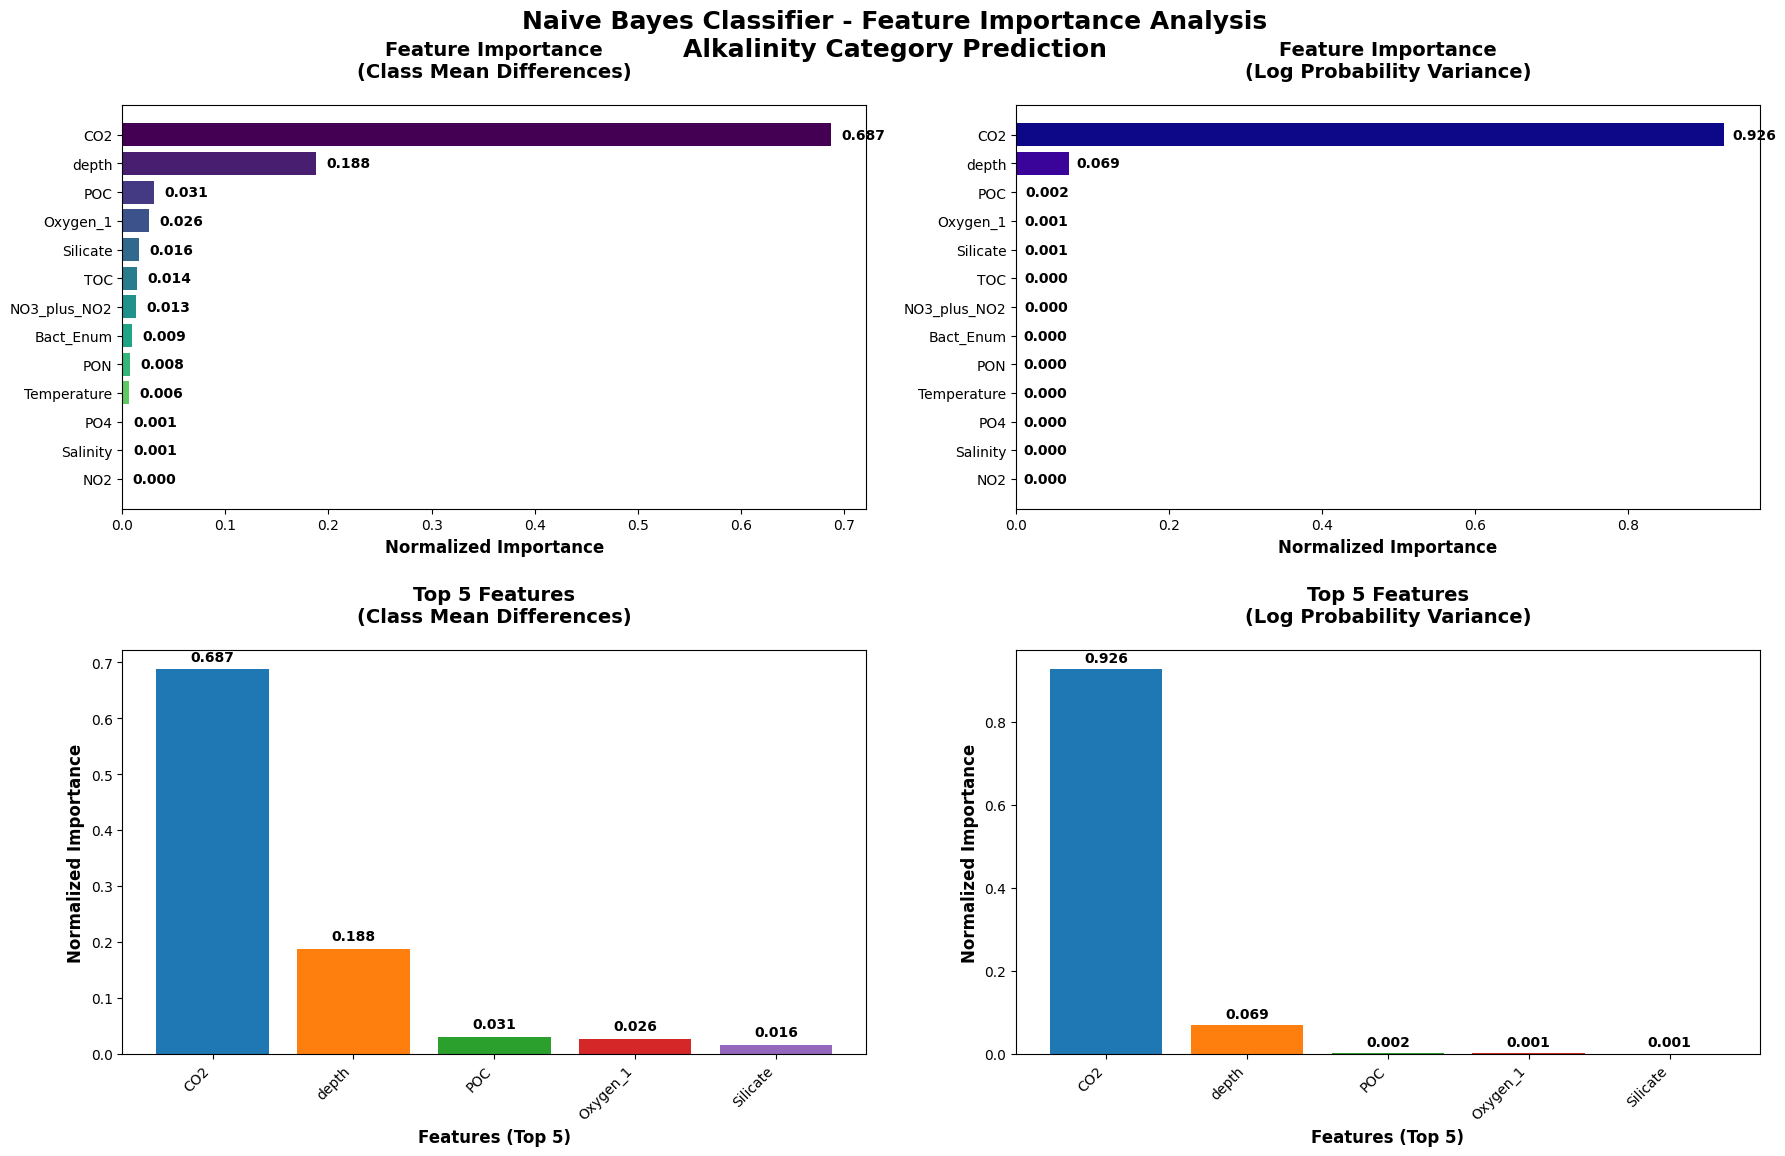

Top 8 features importance visualization saved as 'naive_bayes_feature_importance_top8.png'


<Figure size 1400x800 with 0 Axes>

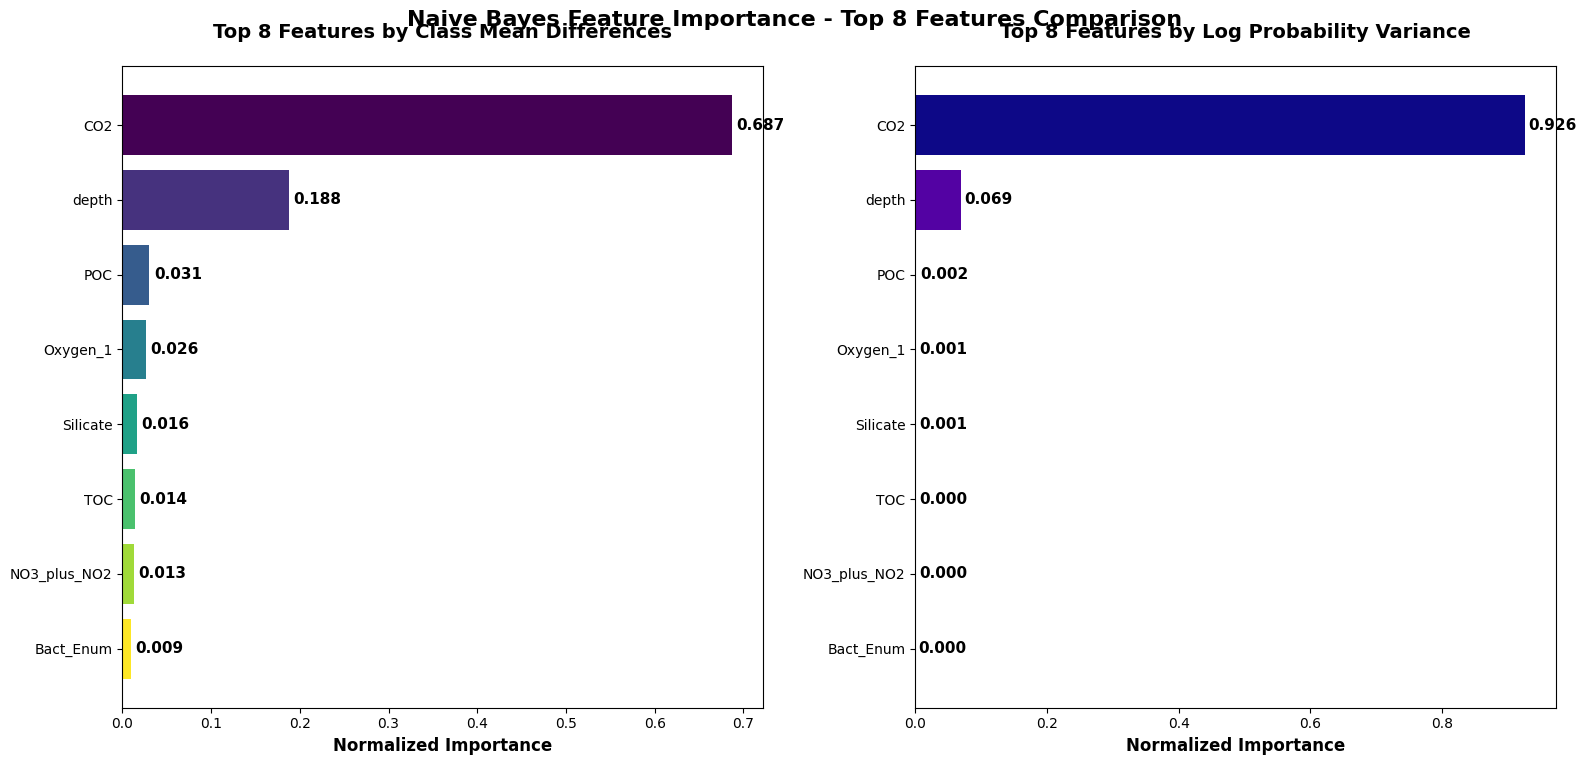

In [ ]:
plt.figure(figsize=(16, 8))


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))


colors1 = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars1 = ax1.barh(feature_importance_df['Feature'], feature_importance_df['Normalized_Importance'], color=colors1)
ax1.set_xlabel('Normalized Importance', fontweight='bold', fontsize=12)
ax1.set_title('Feature Importance\n(Class Mean Differences)', fontweight='bold', fontsize=14, pad=20)
ax1.invert_yaxis()


for i, (bar, value) in enumerate(zip(bars1, feature_importance_df['Normalized_Importance'])):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontweight='bold', fontsize=10)


colors2 = plt.cm.plasma(np.linspace(0, 1, len(feature_importance_df2)))
bars2 = ax2.barh(feature_importance_df2['Feature'], feature_importance_df2['Normalized_Importance'], color=colors2)
ax2.set_xlabel('Normalized Importance', fontweight='bold', fontsize=12)
ax2.set_title('Feature Importance\n(Log Probability Variance)', fontweight='bold', fontsize=14, pad=20)
ax2.invert_yaxis()


for i, (bar, value) in enumerate(zip(bars2, feature_importance_df2['Normalized_Importance'])):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontweight='bold', fontsize=10)


top5_df1 = feature_importance_df.head(5)
bars3 = ax3.bar(range(len(top5_df1)), top5_df1['Normalized_Importance'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax3.set_xlabel('Features (Top 5)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Normalized Importance', fontweight='bold', fontsize=12)
ax3.set_title('Top 5 Features\n(Class Mean Differences)', fontweight='bold', fontsize=14, pad=20)
ax3.set_xticks(range(len(top5_df1)))
ax3.set_xticklabels(top5_df1['Feature'], rotation=45, ha='right')


for bar, value in zip(bars3, top5_df1['Normalized_Importance']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)


top5_df2 = feature_importance_df2.head(5)
bars4 = ax4.bar(range(len(top5_df2)), top5_df2['Normalized_Importance'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax4.set_xlabel('Features (Top 5)', fontweight='bold', fontsize=12)
ax4.set_ylabel('Normalized Importance', fontweight='bold', fontsize=12)
ax4.set_title('Top 5 Features\n(Log Probability Variance)', fontweight='bold', fontsize=14, pad=20)
ax4.set_xticks(range(len(top5_df2)))
ax4.set_xticklabels(top5_df2['Feature'], rotation=45, ha='right')


for bar, value in zip(bars4, top5_df2['Normalized_Importance']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)


fig.suptitle('Naive Bayes Classifier - Feature Importance Analysis\nAlkalinity Category Prediction', 
             fontsize=18, fontweight='bold', y=0.96)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.35)


plt.savefig('naive_bayes_feature_importance_comprehensive.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Comprehensive feature importance visualization saved as 'naive_bayes_feature_importance_comprehensive.png'")
plt.show()


plt.figure(figsize=(14, 8))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


top8_df1 = feature_importance_df.head(8)
bars1 = ax1.barh(range(len(top8_df1)), top8_df1['Normalized_Importance'], 
                 color=plt.cm.viridis(np.linspace(0, 1, len(top8_df1))))
ax1.set_yticks(range(len(top8_df1)))
ax1.set_yticklabels(top8_df1['Feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Normalized Importance', fontweight='bold', fontsize=12)
ax1.set_title('Top 8 Features by Class Mean Differences', fontweight='bold', fontsize=14, pad=20)


for i, (bar, value) in enumerate(zip(bars1, top8_df1['Normalized_Importance'])):
    ax1.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontweight='bold', fontsize=11)


top8_df2 = feature_importance_df2.head(8)
bars2 = ax2.barh(range(len(top8_df2)), top8_df2['Normalized_Importance'], 
                 color=plt.cm.plasma(np.linspace(0, 1, len(top8_df2))))
ax2.set_yticks(range(len(top8_df2)))
ax2.set_yticklabels(top8_df2['Feature'])
ax2.invert_yaxis()
ax2.set_xlabel('Normalized Importance', fontweight='bold', fontsize=12)
ax2.set_title('Top 8 Features by Log Probability Variance', fontweight='bold', fontsize=14, pad=20)


for i, (bar, value) in enumerate(zip(bars2, top8_df2['Normalized_Importance'])):
    ax2.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontweight='bold', fontsize=11)

plt.suptitle('Naive Bayes Feature Importance - Top 8 Features Comparison', 
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.88)


plt.savefig('naive_bayes_feature_importance_top8.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Top 8 features importance visualization saved as 'naive_bayes_feature_importance_top8.png'")
plt.show()

Creating visualization of main dataset with categorical target...
Available columns: ['year_month', 'depth', 'Temperature', 'Salinity', 'Oxygen_1', 'CO2', 'Alkalinity', 'NO3_plus_NO2', 'NO2', 'PO4', 'Silicate', 'POC', 'PON', 'TOC', 'Bact_Enum', 'year', 'Alkalinity_3_bins', 'Alkalinity_quartiles', 'Alkalinity_custom', 'Alkalinity_5_bins', 'Alkalinity_binary', 'Alkalinity_category']
Table visualization saved as 'dataset_head_with_target.png'


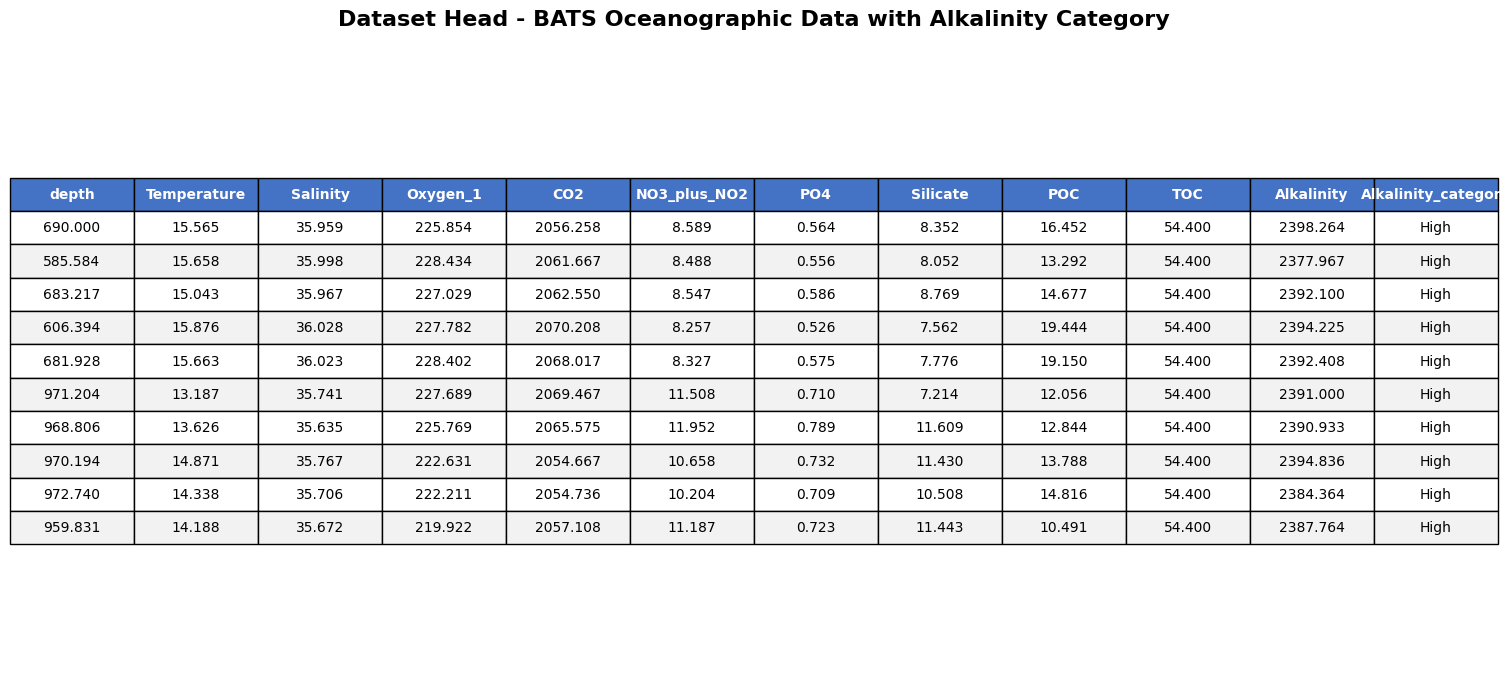


Creating visualization of training set...
Table visualization saved as 'training_set_head.png'


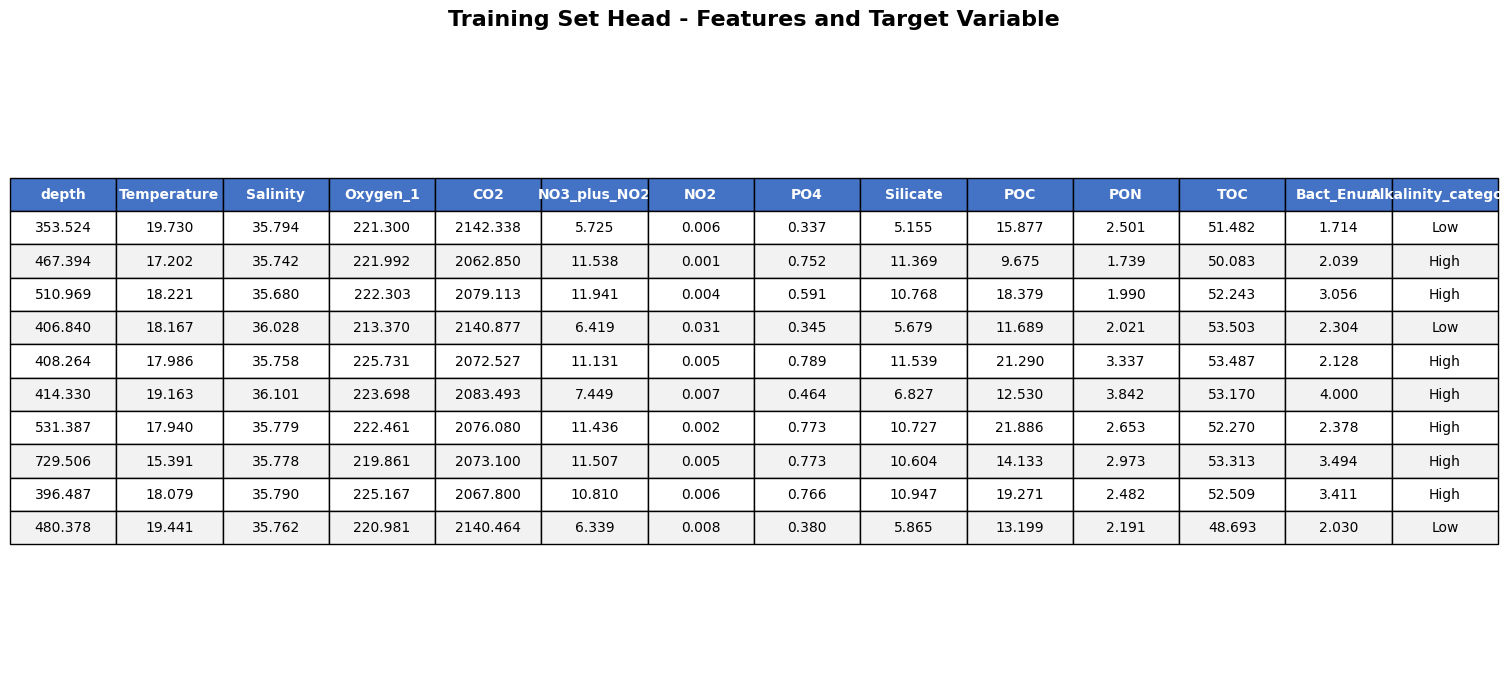


Creating visualization of test set...
Table visualization saved as 'test_set_head.png'


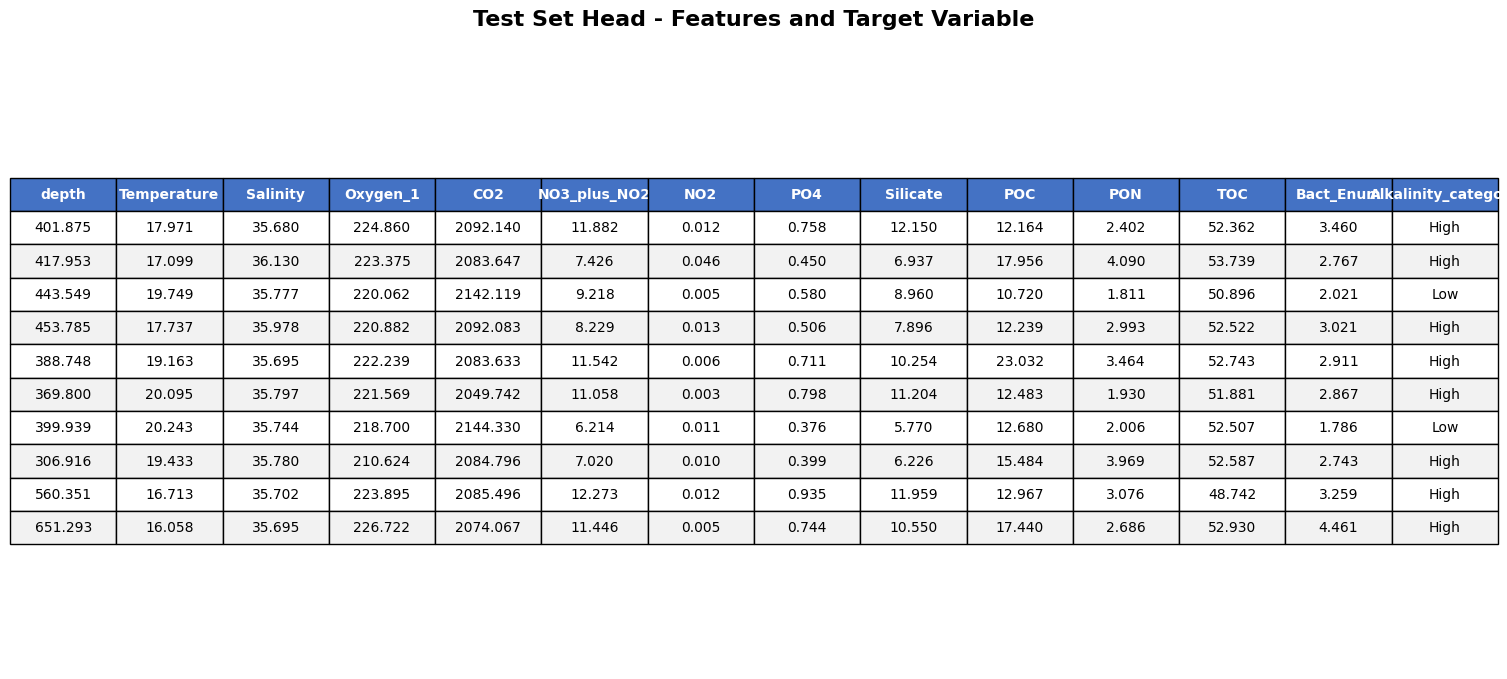


Creating summary statistics visualization...
Summary statistics visualization saved as 'dataset_summary_statistics.png'


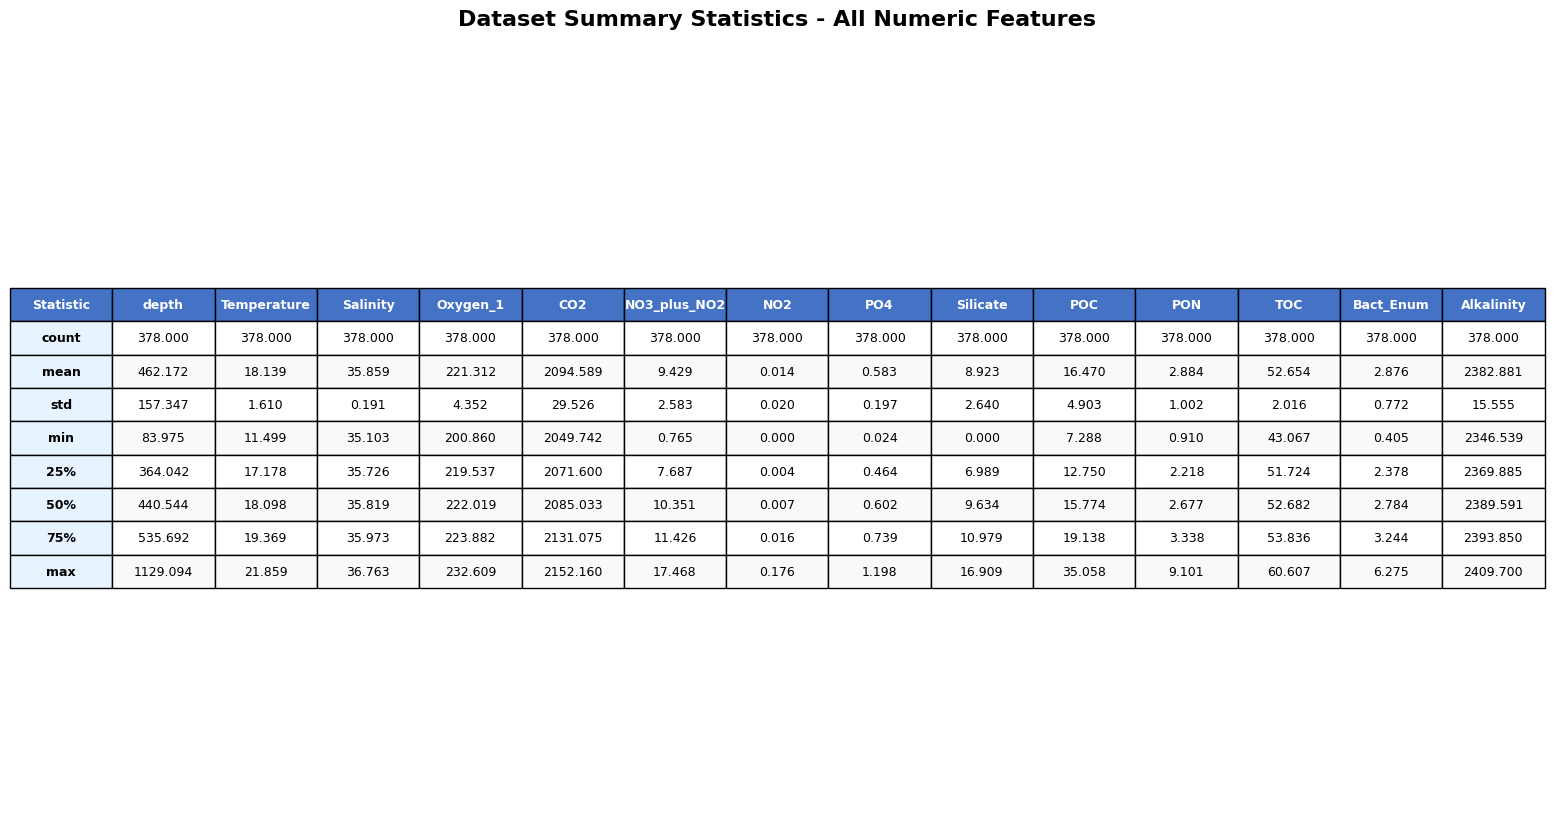


All data table visualizations have been created and saved!


In [23]:
# Create and save data table visualizations as PNG

# Function to create a nice table visualization
def create_table_image(data, title, filename, max_rows=10):
    """Create a professional table image from pandas DataFrame"""
    # Limit the number of rows to display
    display_data = data.head(max_rows)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare table data
    table_data = []
    
    # Add header row
    headers = list(display_data.columns)
    table_data.append(headers)
    
    # Add data rows
    for idx, row in display_data.iterrows():
        row_data = []
        for col in display_data.columns:
            value = row[col]
            # Format numbers nicely
            if pd.api.types.is_numeric_dtype(type(value)) and not pd.isna(value):
                if isinstance(value, (int, np.integer)):
                    row_data.append(str(value))
                elif isinstance(value, (float, np.floating)):
                    row_data.append(f"{value:.3f}")
                else:
                    row_data.append(str(value))
            else:
                row_data.append(str(value))
        table_data.append(row_data)
    
    # Create table
    table = ax.table(cellText=table_data, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)
    
    # Style the header row
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors for better readability
    for i in range(1, len(table_data)):
        color = '#F2F2F2' if i % 2 == 0 else '#FFFFFF'
        for j in range(len(headers)):
            table[(i, j)].set_facecolor(color)
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Save the table
    plt.savefig(filename, dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    print(f"Table visualization saved as '{filename}'")
    plt.show()

# 1. Create visualization of the main dataset head (with categorical target)
print("Creating visualization of main dataset with categorical target...")
print("Available columns:", df.columns.tolist())

# Select key columns for display (including all features plus original and categorical alkalinity)
display_columns = ['depth', 'Temperature', 'Salinity', 'Oxygen_1', 'CO2', 
                  'NO3_plus_NO2', 'PO4', 'Silicate', 'POC', 'TOC', 'Alkalinity', 'Alkalinity_category']

create_table_image(
    df[display_columns].head(10),
    'Dataset Head - BATS Oceanographic Data with Alkalinity Category',
    'dataset_head_with_target.png'
)

# 2. Create visualization of training set head
print("\nCreating visualization of training set...")
# Combine features and target for training set
X_train_display = X_train.copy()
X_train_display['Alkalinity_category'] = y_train
# Reset index to show proper row numbers
X_train_display = X_train_display.reset_index(drop=True)

create_table_image(
    X_train_display.head(10),
    'Training Set Head - Features and Target Variable',
    'training_set_head.png'
)

# 3. Create visualization of test set head
print("\nCreating visualization of test set...")
# Combine features and target for test set
X_test_display = X_test.copy()
X_test_display['Alkalinity_category'] = y_test
# Reset index to show proper row numbers
X_test_display = X_test_display.reset_index(drop=True)

create_table_image(
    X_test_display.head(10),
    'Test Set Head - Features and Target Variable',
    'test_set_head.png'
)

# 4. Create a summary statistics table
print("\nCreating summary statistics visualization...")
summary_stats = df[feature_columns + ['Alkalinity']].describe()
summary_stats = summary_stats.round(3)

fig, ax = plt.subplots(figsize=(18, 10))
ax.axis('tight')
ax.axis('off')

# Prepare summary table data
table_data = []
# Add header row
headers = ['Statistic'] + list(summary_stats.columns)
table_data.append(headers)

# Add each statistic row
for stat in summary_stats.index:
    row_data = [stat]
    for col in summary_stats.columns:
        value = summary_stats.loc[stat, col]
        row_data.append(f"{value:.3f}")
    table_data.append(row_data)

# Create table
table = ax.table(cellText=table_data, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2)

# Style the header row
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style the statistic name column
for i in range(1, len(table_data)):
    table[(i, 0)].set_facecolor('#E7F3FF')
    table[(i, 0)].set_text_props(weight='bold')

# Alternate row colors for data columns
for i in range(1, len(table_data)):
    color = '#F8F9FA' if i % 2 == 0 else '#FFFFFF'
    for j in range(1, len(headers)):
        table[(i, j)].set_facecolor(color)

plt.title('Dataset Summary Statistics - All Numeric Features', 
          fontsize=16, fontweight='bold', pad=20)

plt.savefig('dataset_summary_statistics.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("Summary statistics visualization saved as 'dataset_summary_statistics.png'")
plt.show()

print("\nAll data table visualizations have been created and saved!")